In [73]:
import os
import numpy as np
import pandas as pd
import sys
from importlib import reload

# ugly workaround for now
sys.path.append('/Users/Device6/Documents/Research/bgoodlab/microbiome_codiv/comigration_metagenomics/')
from utils import snv_utils, metadata_utils
import config

In [74]:
from utils import pairwise_utils

pairwise_helper = pairwise_utils.PairwiseHelper(databatch=config.databatch)

In [75]:
reload(tsimane_datahelper)

<module 'tsimane_datahelper' from '/Users/Device6/Documents/Research/bgoodlab/close_pair_hmm/examples/example2/tsimane_datahelper.py'>

In [76]:
len(pairwise_helper.hgt_summary['species'].unique())

603

In [77]:
import tsimane_datahelper
species = 'Blautia_A_ammoniilytica'
species_dat = pairwise_helper.hgt_summary[pairwise_helper.hgt_summary['species']==species]
dh = tsimane_datahelper.DataHelper_Hadza_Tsimane(species=species, drep_summary=species_dat)

117 multi-allelic sites masked


In [84]:
dh.snv_data.core_4D_coverage.reset_index()['Contig'].value_counts()

Contig
Hadza_PheChl_Fiber-Hadza-Nepal_E_18_1662__NODE_2854_length_37200_cov_4.759394    1989
Hadza_PheChl_Fiber-Hadza-Nepal_E_18_1662__NODE_3097_length_35344_cov_4.579182    1694
Hadza_PheChl_Fiber-Hadza-Nepal_E_18_1662__NODE_2161_length_43929_cov_4.623985    1640
Hadza_PheChl_Fiber-Hadza-Nepal_E_18_1662__NODE_2103_length_44857_cov_4.624498    1584
Hadza_PheChl_Fiber-Hadza-Nepal_E_18_1662__NODE_3647_length_31667_cov_5.001773    1418
                                                                                 ... 
Hadza_PheChl_Fiber-Hadza-Nepal_E_18_1662__NODE_17420_length_8643_cov_4.630633      59
Hadza_PheChl_Fiber-Hadza-Nepal_E_18_1662__NODE_25382_length_6067_cov_3.893990      50
Hadza_PheChl_Fiber-Hadza-Nepal_E_18_1662__NODE_23782_length_6458_cov_4.892650      45
Hadza_PheChl_Fiber-Hadza-Nepal_E_18_1662__NODE_53626_length_2999_cov_4.998973      36
Hadza_PheChl_Fiber-Hadza-Nepal_E_18_1662__NODE_9010_length_15439_cov_4.279456      35
Name: count, Length: 86, dtype: int64

In [70]:
close_pairs = dh.get_close_pairs(perc_id_threshold=0.1)

In [39]:
rand_pair = dh.get_random_pair()

# Debug specific pairs

In [36]:
rand_pair = ('Alistipes_onderdonkii__SRS014459', 'Alistipes_onderdonkii__SRS294866')
# rand_pair = ('Alistipes_onderdonkii__SRS014313', 'Alistipes_onderdonkii__SRS294866')

In [37]:
dh.drep_summary.set_index(['genome1', 'genome2']).loc[rand_pair]

querry                Alistipes_onderdonkii__SRS014459.fa
reference             Alistipes_onderdonkii__SRS294866.fa
ani                                              0.993977
alignment_coverage                               0.849927
primary_cluster                                         0
comps                                                1378
identicle                                             799
total_aligned                                     1635067
name                             Alistipes_onderdonkii_v7
perc_id                                          0.579826
study_x                                               HMP
study_y                                             China
cpop                                            Different
species                             Alistipes_onderdonkii
Name: (Alistipes_onderdonkii__SRS014459, Alistipes_onderdonkii__SRS294866), dtype: object

In [38]:
snv_vec, contigs, coords = dh.get_pair_snp_info(rand_pair)

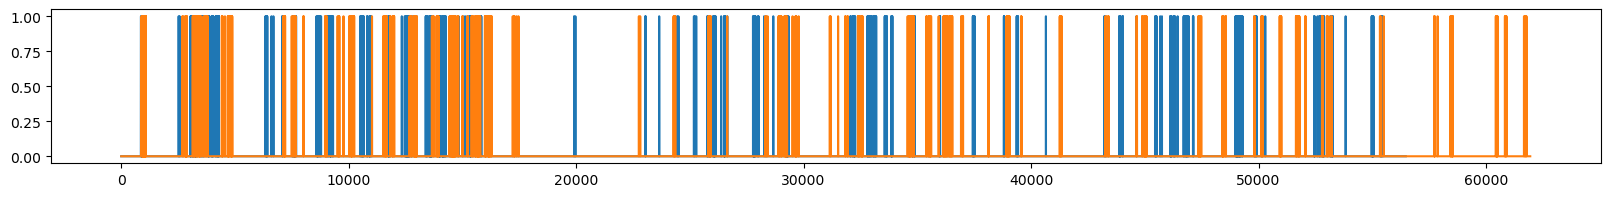

In [42]:
import matplotlib.pyplot as plt
plt.subplots(1,1,figsize=(20,2))
plt.plot(snv_vec)
plt.plot(snv_vec1)

In [71]:
import cphmm.config
import cphmm.recomb_inference as ri

model = infer_pipelines.init_hmm(dh.species, dh.genome_len, 
                     cphmm.config.HMM_BLOCK_SIZE)

In [72]:
# debugging specific contigs
import cphmm.seq_manip as seq_manip
block_size = cphmm.config.HMM_BLOCK_SIZE

index_offset = 0
for contig in pd.unique(contigs):
        # iterate over contigs; similar to run length dist calculation
        subvec = snv_vec[contigs==contig]
        blk_seq = seq_manip.to_block(subvec, block_size).reshape((-1, 1))
        # to reduce effect of correlated mutation over short distances
        blk_seq_fit = (blk_seq > 0).astype(float)
        if (np.sum(blk_seq) == 0) or (len(blk_seq) < 100):
            # some time will have an identical contig
            # have to skip otherwise will mess up hmm
            starts = [np.array([])]
            ends = [np.array([])]
            clonal_seq = blk_seq  # full sequence is clonal
        else:
            try:
                starts, ends, clonal_seq = ri.decode_and_count_transfers(
                    blk_seq_fit, model, sequence_with_snps=blk_seq, index_offset=index_offset,
                    clade_cutoff_bin=None)
            except ValueError as e:
                 print('Error in contig:', contig)
                 print(e)
                 break

In [70]:
blk_seq

array([[1]])

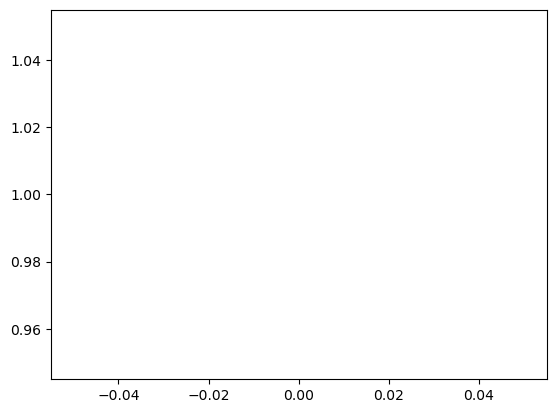

In [69]:
plt.plot(blk_seq)

In [64]:
clonal_div, genome_len, clonal_len, transfer_dat = \
                ri.infer(snv_vec, contigs, model, cphmm.config.HMM_BLOCK_SIZE, clade_cutoff_bin=None)

ValueError: rows of transmat_ must sum to 1.0 (got [nan  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
  1.  1.  1.  1.  1.])

# Compute prior for species

In [43]:
from importlib import reload
reload(cphmm.prior)

<module 'cphmm.prior' from '/Users/Device6/Documents/Research/bgoodlab/close_pair_hmm/cphmm/prior.py'>

In [44]:
import cphmm.prior

local_divs, genome_divs = cphmm.prior.sample_blocks(dh)

In [45]:
divs, counts = cphmm.prior.compute_div_histogram(local_divs, genome_divs, separate_clades=False)
cphmm.prior.save_prior(divs, counts, dh.species)

# Infer recombination for species

In [4]:
import cphmm.infer_pipelines as infer_pipelines

infer_summary, transfer_summary = infer_pipelines.infer_pairs(dh, dh.get_close_pairs(perc_id_threshold=0.1))

Inferred pair ('Evtepia_sp934567745__Hadza_MoBio_hadza_A_D_P_1_1512', 'Evtepia_sp934567745__Hadza_MoBio_hadza_E_H_D_1_1951')
Inferred pair ('Evtepia_sp934567745__Hadza_MoBio_hadza_A_D_P_1_1512', 'Evtepia_sp934567745__Hadza_MoBio_hadza_E_H_P_21_2150')
Inferred pair ('Evtepia_sp934567745__Hadza_MoBio_hadza_E_H_D_1_1951', 'Evtepia_sp934567745__Hadza_MoBio_hadza_E_H_P_21_2150')
Inferred pair ('Evtepia_sp934567745__Hadza_MoBio_hadza_A_D_P_1_1512', 'Evtepia_sp934567745__Hadza_MoBio_hadza_E_H_P_7_2143')
Inferred pair ('Evtepia_sp934567745__Hadza_MoBio_hadza_E_H_D_1_1951', 'Evtepia_sp934567745__Hadza_MoBio_hadza_E_H_P_7_2143')
Inferred pair ('Evtepia_sp934567745__Hadza_MoBio_hadza_E_H_P_21_2150', 'Evtepia_sp934567745__Hadza_MoBio_hadza_E_H_P_7_2143')
Inferred pair ('Evtepia_sp934567745__Hadza_MoBio_hadza_A_D_P_1_1512', 'Evtepia_sp934567745__Hadza_MoBio_hadza_I_L_B_9_2646')
Inferred pair ('Evtepia_sp934567745__Hadza_MoBio_hadza_E_H_D_1_1951', 'Evtepia_sp934567745__Hadza_MoBio_hadza_I_L_B_9_2646

In [5]:
infer_summary.set_index(['genome1', 'genome2'], inplace=True)

In [6]:
def div_to_years(div, gen_per_day=1, mut_rate=4.08e-10):
    mut_per_year = mut_rate * 365 * gen_per_day
    return div / mut_per_year

drep_summary = dh.drep_summary.set_index(['genome1', 'genome2'])
infer_summary['ani'] = drep_summary.loc[infer_summary.index, 'ani']
infer_summary['perc_id'] = drep_summary.loc[infer_summary.index, 'perc_id']
infer_summary['div_years'] = div_to_years(infer_summary['est_div'])

Text(0.5, 1.0, 'Evtepia_sp934567745')

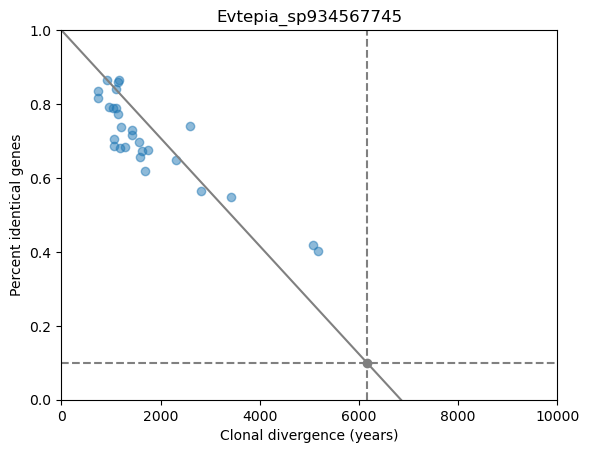

In [13]:
import matplotlib.pyplot as plt
x = infer_summary['div_years']
y = infer_summary['perc_id']

perc_id_threshold = 0.4
x_fit = x[y >= perc_id_threshold]
y_fit = y[y >= perc_id_threshold]

plt.scatter(x_fit, y_fit, alpha=0.5)

# fit the slope of y= 1- b * x
from scipy.optimize import curve_fit
def func(x, b):
    return 1 - b * x

popt, pcov = curve_fit(func, x_fit, y_fit)

year_at_10p = 0.9 / popt

xplot = np.linspace(0, 10000)
plt.plot(xplot, func(xplot, *popt), '-', color='grey')

plt.scatter(year_at_10p, 0.1, color='grey')
plt.axvline(x=year_at_10p, color='grey', linestyle='--')
plt.axhline(y=0.1, color='grey', linestyle='--')

plt.ylim([0, 1])
plt.xlim([0, 10000])

plt.xlabel('Clonal divergence (years)')
plt.ylabel('Percent identical genes')
plt.title(species)

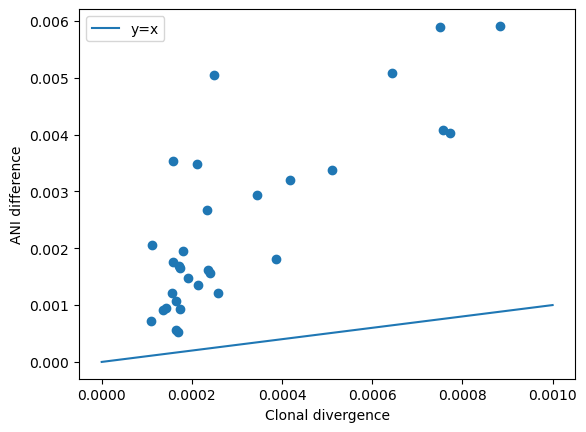

In [93]:
mask = infer_summary['perc_id'] > 0.2
plt.scatter(infer_summary['est_div'][mask], 1 - infer_summary['ani'][mask])
plt.ylabel('ANI difference')
plt.xlabel('Clonal divergence')
xs = np.linspace(0, 1e-3)
plt.plot(xs, xs, label='y=x')
plt.legend()

In [64]:
infer_summary

naive_div  \
genome1                                            genome2                                                         
Evtepia_sp934567745__Hadza_MoBio_hadza_A_D_P_1_... Evtepia_sp934567745__Hadza_MoBio_hadza_E_H_P_21...   0.000110   
Evtepia_sp934567745__Hadza_MoBio_hadza_E_H_P_7_... Evtepia_sp934567745__Hadza_MoBio_hadza_I_L_F_5_...   0.000245   
                                                   Evtepia_sp934567745__Hadza_PheChl_Fiber_Hadza_N...   0.000162   
Evtepia_sp934567745__Hadza_MoBio_hadza_I_L_F_5_... Evtepia_sp934567745__Hadza_PheChl_Fiber_Hadza_N...   0.000262   
Evtepia_sp934567745__Hadza_PheChl_Fiber_Hadza_N... Evtepia_sp934567745__Hadza_PheChl_Fiber_Hadza_N...   0.000196   
Evtepia_sp934567745__TS_ADULT_11                   Evtepia_sp934567745__TS_ADULT_141                    0.000268   
Evtepia_sp934567745__TS_ADULT_117                  Evtepia_sp934567745__TS_ADULT_141                    0.000275   
Evtepia_sp934567745__TS_ADULT_141                  Evtepia_sp934567745__TS_ADULT_146                    0.000435   
Evtepia_sp934567745__TS_ADULT_11                   Evtepia_sp934567745__TS_ADULT_146                    0.000219   
Evtepia_sp934567745__TS_ADULT_117                  Evtepia_sp934567745__TS_ADULT_146                    0.000293   
Evtepia_sp934567745__TS_ADULT_141                  Evtepia_sp934567745__TS_ADULT_163                    0.000240   
Evtepia_sp934567745__TS_ADULT_146                  Evtepia_sp934567745__TS_ADULT_163                    0.000482   
Evtepia_sp934567745__TS_ADULT_11                   Evtepia_sp934567745__TS_ADULT_163                    0.000177   
Evtepia_sp934567745__TS_ADULT_117                  Evtepia_sp934567745__TS_ADULT_163                    0.000182   
Evtepia_sp934567745__TS_ADULT_15                   Evtepia_sp934567745__TS_ADULT_33                     0.000702   
Evtepia_sp934567745__TS_ADULT_21                   Evtepia_sp934567745__TS_ADULT_33                     0.000745   
Evtepia_sp934567745__TS_ADULT_15                   Evtepia_sp934567745__TS_ADULT_64                     0.000213   
Evtepia_sp934567745__TS_ADULT_33                   Evtepia_sp934567745__TS_ADULT_64                     0.000301   
Evtepia_sp934567745__TS_ADULT_21                   Evtepia_sp934567745__TS_ADULT_64                     0.000477   
Evtepia_sp934567745__TS_ADULT_141                  Evtepia_sp934567745__TS_ADULT_173                    0.000245   
Evtepia_sp934567745__TS_ADULT_146                  Evtepia_sp934567745__TS_ADULT_173                    0.000449   
Evtepia_sp934567745__TS_ADULT_163                  Evtepia_sp934567745__TS_ADULT_173                    0.000186   
Evtepia_sp934567745__TS_ADULT_11                   Evtepia_sp934567745__TS_ADULT_173                    0.000163   
Evtepia_sp934567745__TS_ADULT_117                  Evtepia_sp934567745__TS_ADULT_173                    0.000181   
Evtepia_sp934567745__TS_ADULT_15                   Evtepia_sp934567745__TS_ADULT_21                     0.000598   
Evtepia_sp934567745__TS_ADULT_11                   Evtepia_sp934567745__TS_ADULT_117                    0.000109   

                                                                                                        est_div  \
genome1                                            genome2                                                        
Evtepia_sp934567745__Hadza_MoBio_hadza_A_D_P_1_... Evtepia_sp934567745__Hadza_MoBio_hadza_E_H_P_21...  0.000111   
Evtepia_sp934567745__Hadza_MoBio_hadza_E_H_P_7_... Evtepia_sp934567745__Hadza_MoBio_hadza_I_L_F_5_...  0.000180   
                                                   Evtepia_sp934567745__Hadza_PheChl_Fiber_Hadza_N...  0.000137   
Evtepia_sp934567745__Hadza_MoBio_hadza_I_L_F_5_... Evtepia_sp934567745__Hadza_PheChl_Fiber_Hadza_N...  0.000233   
Evtepia_sp934567745__Hadza_PheChl_Fiber_Hadza_N... Evtepia_sp934567745__Hadza_PheChl_Fiber_Hadza_N...  0.000155   
Evtepia_sp934567745__TS_ADULT_11                 

# Test specific pairs

In [33]:
genome1 = transfer_summary.iloc[0]['genome1']
genome2 = transfer_summary.iloc[0]['genome2']

snv_vec, contigs, locs = dh.get_pair_snp_info((genome1, genome2))

In [35]:
contigs[9659],contigs[9689], 

(np.str_('TS_ADULT_173__NODE_1459_length_58153_cov_11.107583'),
 np.str_('TS_ADULT_173__NODE_1459_length_58153_cov_11.107583'))

(9000.0, 10000.0)

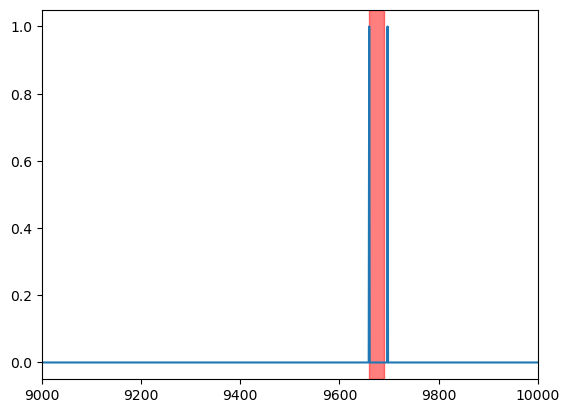

In [36]:
import matplotlib.pyplot as plt

plt.plot(snv_vec)

plt.axvspan(9659.0, 9689.0, color='red', alpha=0.5)
plt.xlim([9000, 10000])